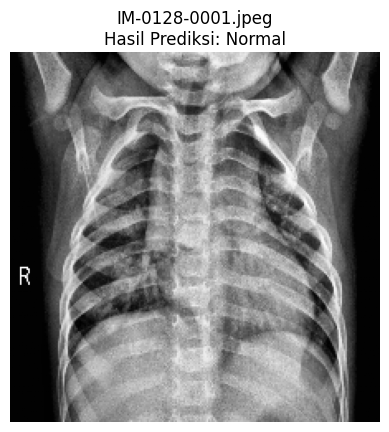

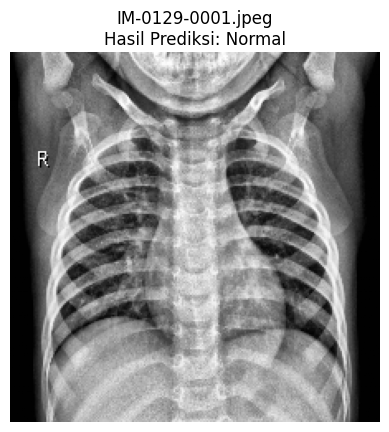

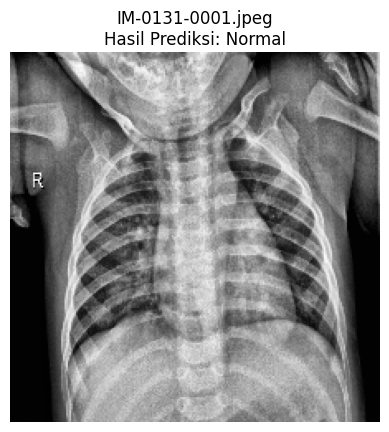

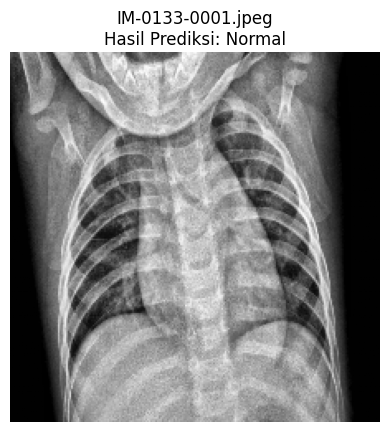

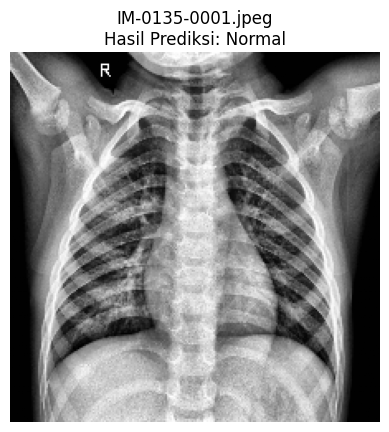

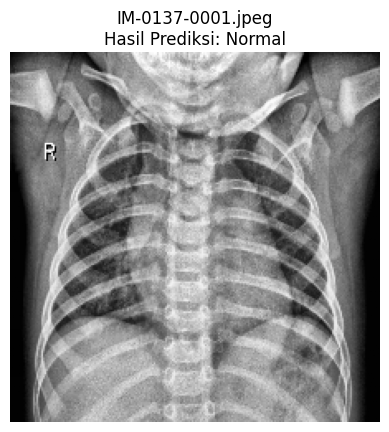

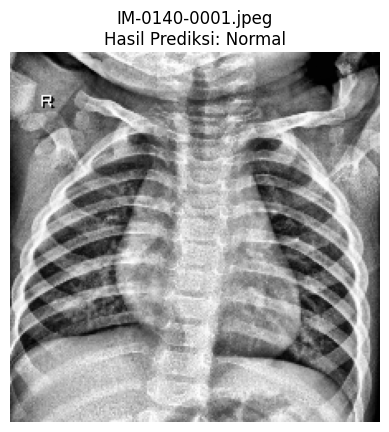

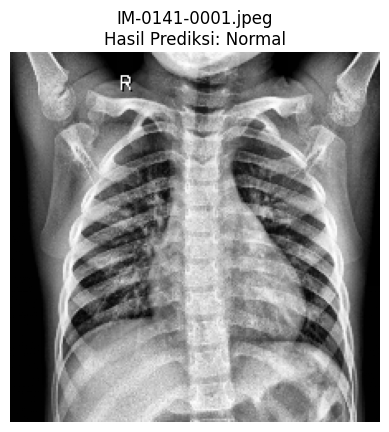

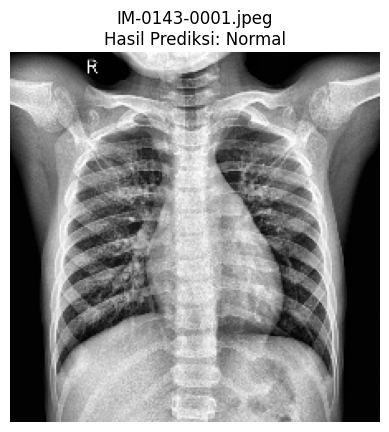

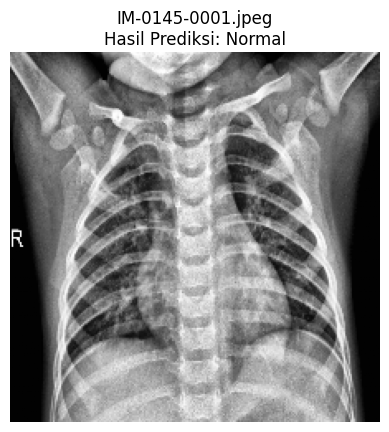

In [11]:
import os
import cv2
import numpy as np
import pyfeats
import joblib
import matplotlib.pyplot as plt

# ======== Load Model dan Komponen ========
model = joblib.load("model_svm.pkl")
scaler = joblib.load("scaler.pkl")
mask = joblib.load("best_mask_fos.pkl")

# ======== Mapping kelas secara manual (PASTIKAN URUT SESUAI TRAINING!) ========
class_labels = ['Normal', 'Tuberculosis']  # GANTI sesuai kelas biner kamu

# ======== Preprocessing Gambar ========
def preprocess_image(img_path, size=(224, 224)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Gagal membaca gambar dari {img_path}")
    img = cv2.resize(img, size)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    return img

# ======== Ekstraksi FOS ========
def extract_fos(img):
    mask_img = np.ones_like(img)
    fos_feats, _ = pyfeats.fos(img, mask_img)
    return np.array(fos_feats[:10])

# ======== Prediksi dan Tampilkan Judul Gambar ========
def predict_images_in_folder(folder_path, max_images=None):
    supported_ext = (".jpg", ".jpeg", ".png")
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(supported_ext)]
    image_files = sorted(image_files)
    if max_images is not None:
        image_files = image_files[:max_images]

    for filename in image_files:
        img_path = os.path.join(folder_path, filename)
        try:
            img = preprocess_image(img_path)
            fos = extract_fos(img).reshape(1, -1)
            features_filtered = fos[:, mask]
            features_scaled = scaler.transform(features_filtered)

            prediction = model.predict(features_scaled)[0]  # hasil: 0 atau 1
            label_name = class_labels[int(prediction)]       # pastikan pakai indeks ke list class_labels

            # Tampilkan gambar dengan judul yang benar
            plt.imshow(img, cmap='gray')
            plt.title(f"{filename}\nHasil Prediksi: {label_name}")
            plt.axis('off')
            plt.show()

        except Exception as e:
            print(f"❌ Error saat memproses {filename}: {e}")

# ======== Eksekusi Utama ========
if __name__ == "__main__":
    folder_path = "C:/SKRIPSI/Dataset/NORMAL"
    predict_images_in_folder(folder_path, max_images=10)
